In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

df = pd.read_csv('cleaned_data.csv', parse_dates=['date'])
print("Cleaned data loaded:", df.shape)
df.head()

Cleaned data loaded: (27784, 9)


,date,position,song,artist,popularity,album_type,total_tracks,is_explicit,duration_min
0,2024-05-18,1,Like Crazy,Jimin,93,single,6,False,3.54
1,2024-05-18,2,UNFORGIVEN (feat. Nile Rodgers),LE SSERAFIM,87,album,13,False,3.04
2,2024-05-18,3,Spicy,aespa,81,single,6,False,3.28
3,2024-05-18,4,I AM,IVE,89,album,11,False,3.06
4,2024-05-18,5,Queencard,(G)I-DLE,71,single,6,False,2.69


In [3]:
#popularity distribution
print("Popularity Stats:")
print(f"  Mean   : {df['popularity'].mean():.2f}")
print(f"  Median : {df['popularity'].median():.2f}")
print(f"  Min    : {df['popularity'].min()}")
print(f"  Max    : {df['popularity'].max()}")
print(f"  Std Dev: {df['popularity'].std():.2f}")

Popularity Stats:
  Mean   : 76.93
  Median : 79.00
  Min    : 0
  Max    : 100
  Std Dev: 12.91


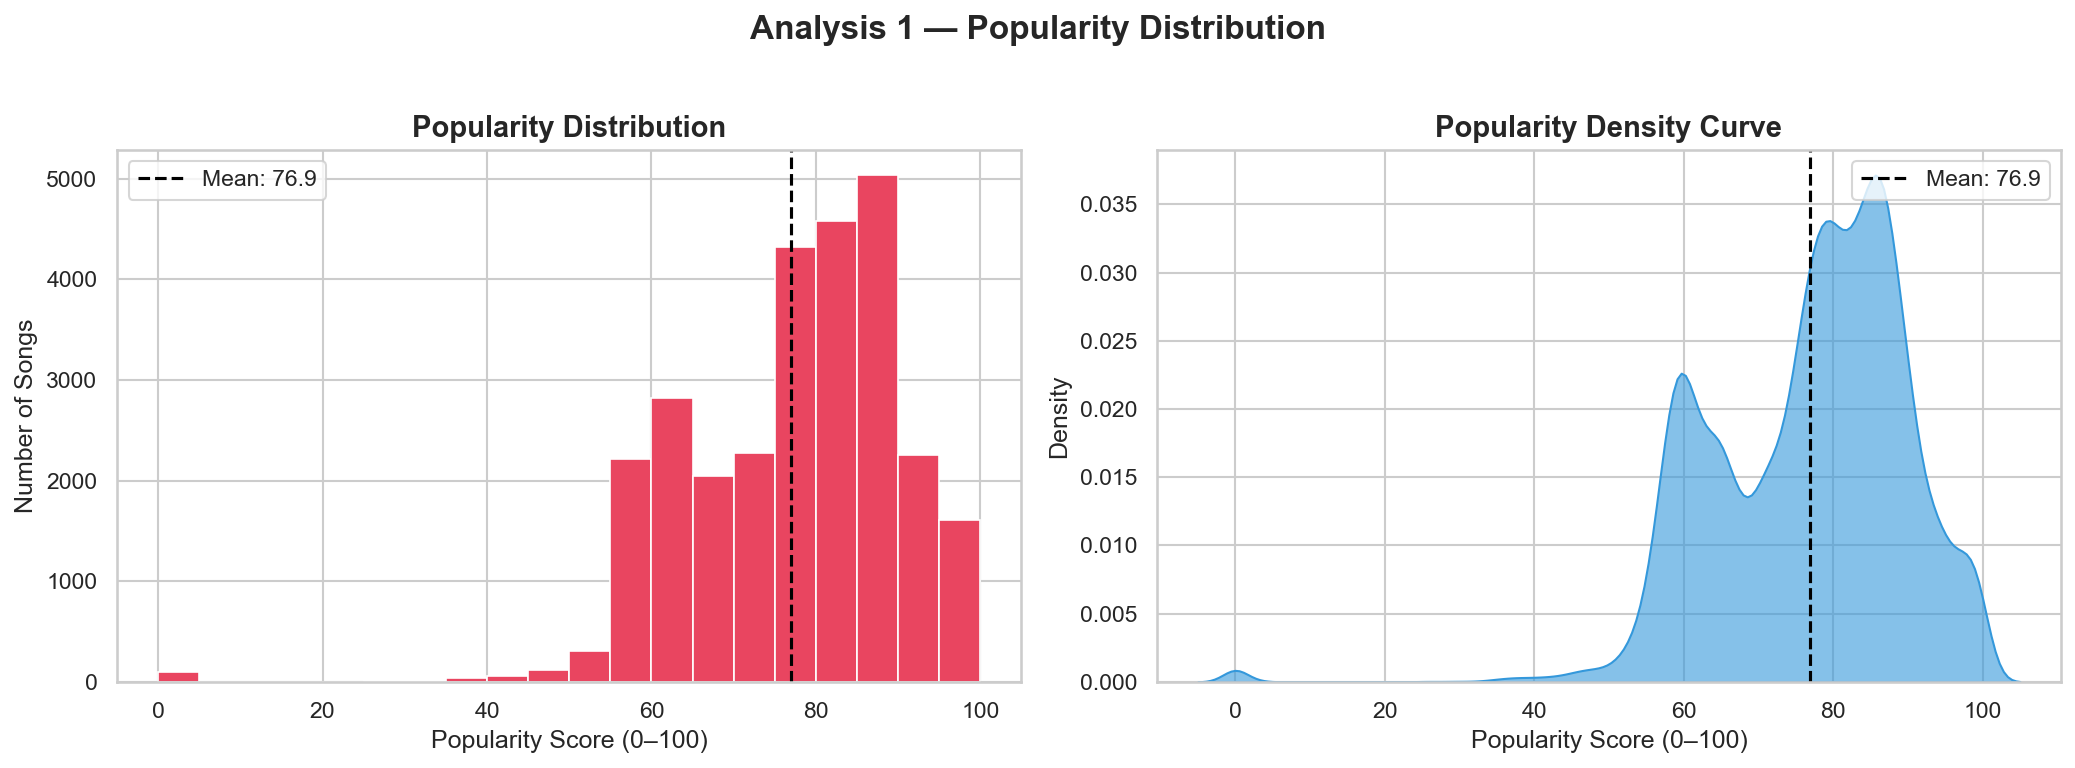

Plot saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Histogram
axes[0].hist(df['popularity'], bins=20, color='#e94560', edgecolor='white', linewidth=0.8)
axes[0].set_title('Popularity Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Popularity Score (0–100)')
axes[0].set_ylabel('Number of Songs')
axes[0].axvline(df['popularity'].mean(), color='black', linestyle='--', linewidth=1.5, label=f"Mean: {df['popularity'].mean():.1f}")
axes[0].legend()

# Right — KDE (smooth curve version of histogram)
sns.kdeplot(df['popularity'], ax=axes[1], fill=True, color='#3498db', alpha=0.6)
axes[1].set_title('Popularity Density Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Popularity Score (0–100)')
axes[1].axvline(df['popularity'].mean(), color='black', linestyle='--', linewidth=1.5, label=f"Mean: {df['popularity'].mean():.1f}")
axes[1].legend()

plt.suptitle('Analysis 1 — Popularity Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_popularity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [5]:
top_artists = df['artist'].value_counts().head(10)
print("Top 10 Most Charted Artists:")
print(top_artists)

Top 10 Most Charted Artists:
Lim Young Woong    4801
Jimin              4359
NewJeans           2906
Jung Kook          1951
V                  1385
LE SSERAFIM         948
aespa               911
RIIZE               533
IVE                 496
DAY6                435
Name: artist, dtype: int64


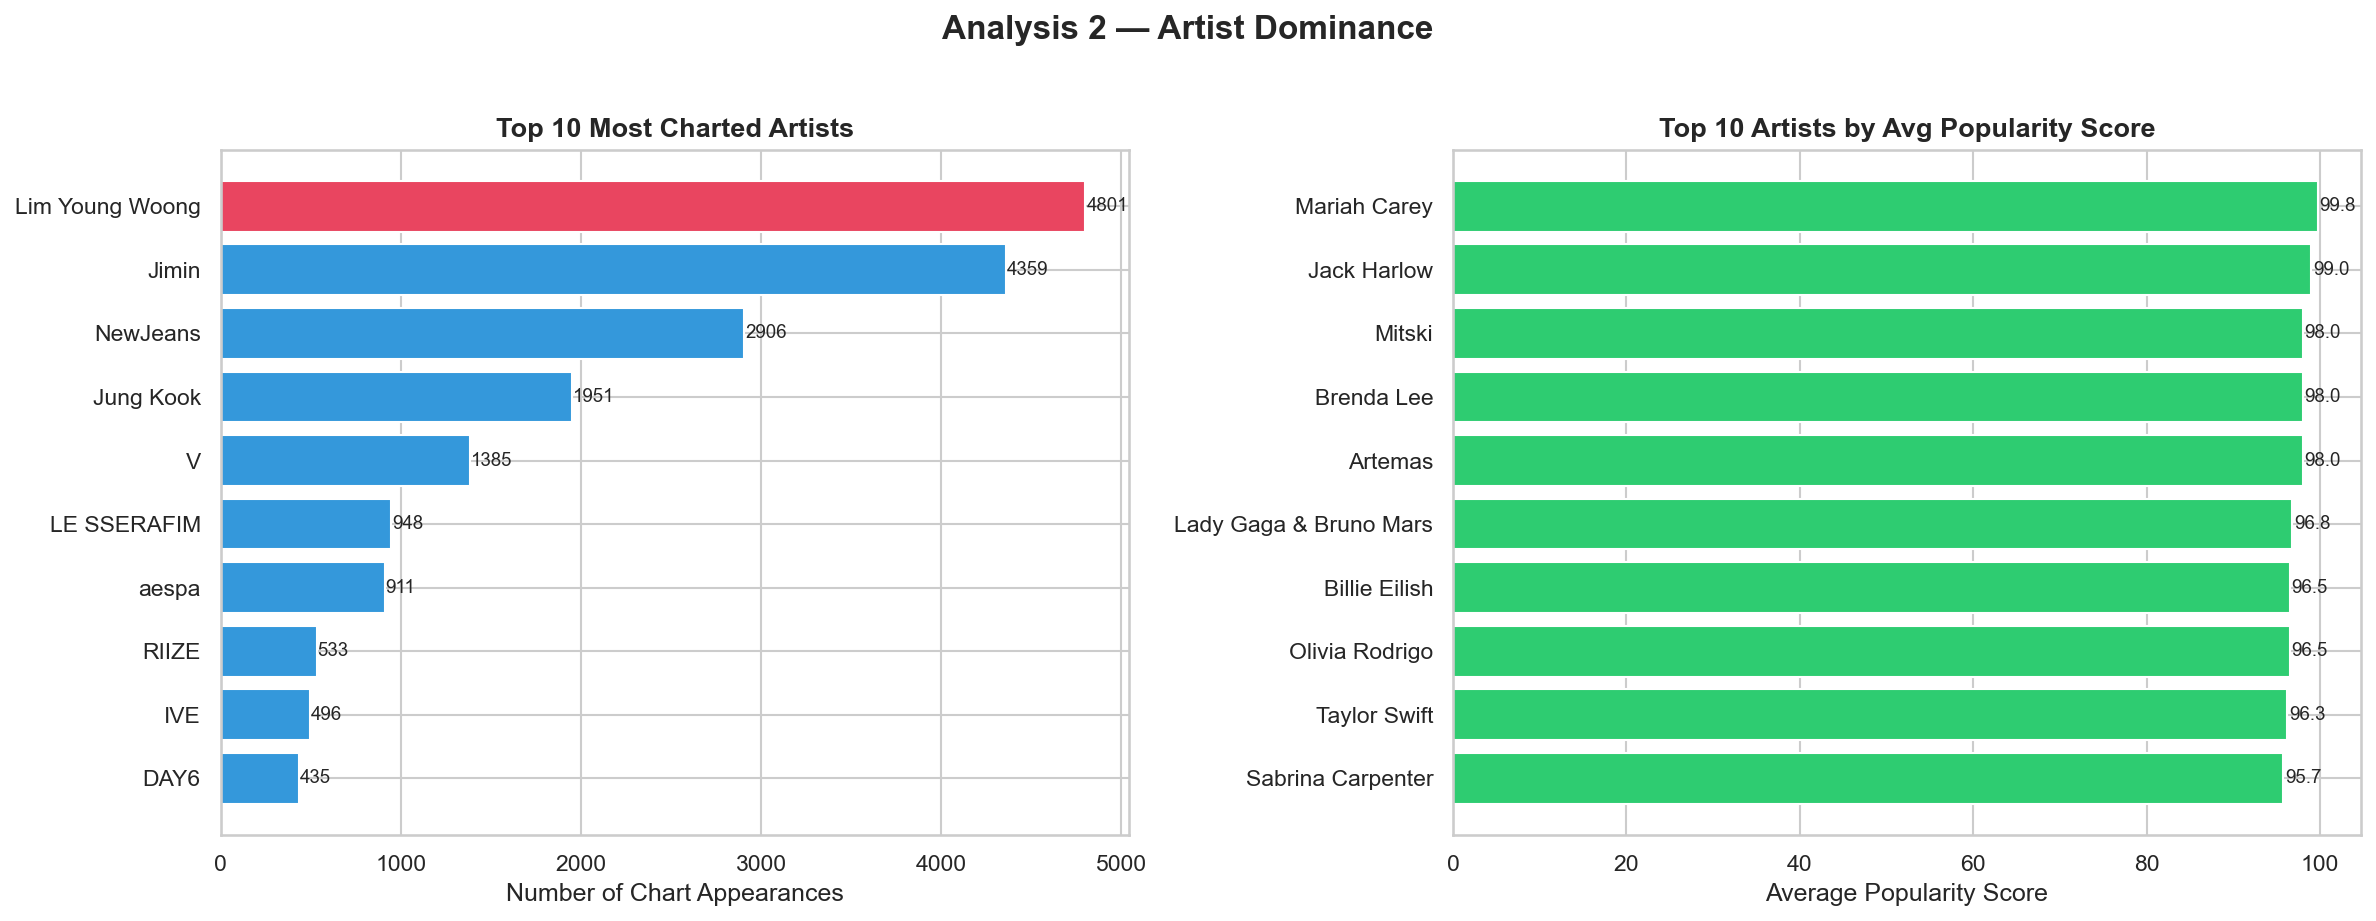

Plot saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — Top 10 by chart appearances
colors_bar = ['#e94560' if i == 0 else '#3498db' for i in range(10)]

axes[0].barh(top_artists.index[::-1], top_artists.values[::-1], color=colors_bar[::-1], edgecolor='white')
axes[0].set_title('Top 10 Most Charted Artists', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Chart Appearances')
for i, v in enumerate(top_artists.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Right — Top 10 by average popularity
avg_pop = df.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(10)
axes[1].barh(avg_pop.index[::-1], avg_pop.values[::-1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Top 10 Artists by Avg Popularity Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Popularity Score')
for i, v in enumerate(avg_pop.values[::-1]):
    axes[1].text(v + 0.2, i, f"{v:.1f}", va='center', fontsize=9)

plt.suptitle('Analysis 2 — Artist Dominance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/02_artist_dominance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [7]:
print("Album Type Distribution:")
print(df['album_type'].value_counts())
print("\nAverage Popularity by Album Type:")
print(df.groupby('album_type')['popularity'].mean().round(2).sort_values(ascending=False))

Album Type Distribution:
single         17938
album           9845
compilation        1
Name: album_type, dtype: int64

Average Popularity by Album Type:
album_type
single         78.43
album          74.20
compilation    27.00
Name: popularity, dtype: float64


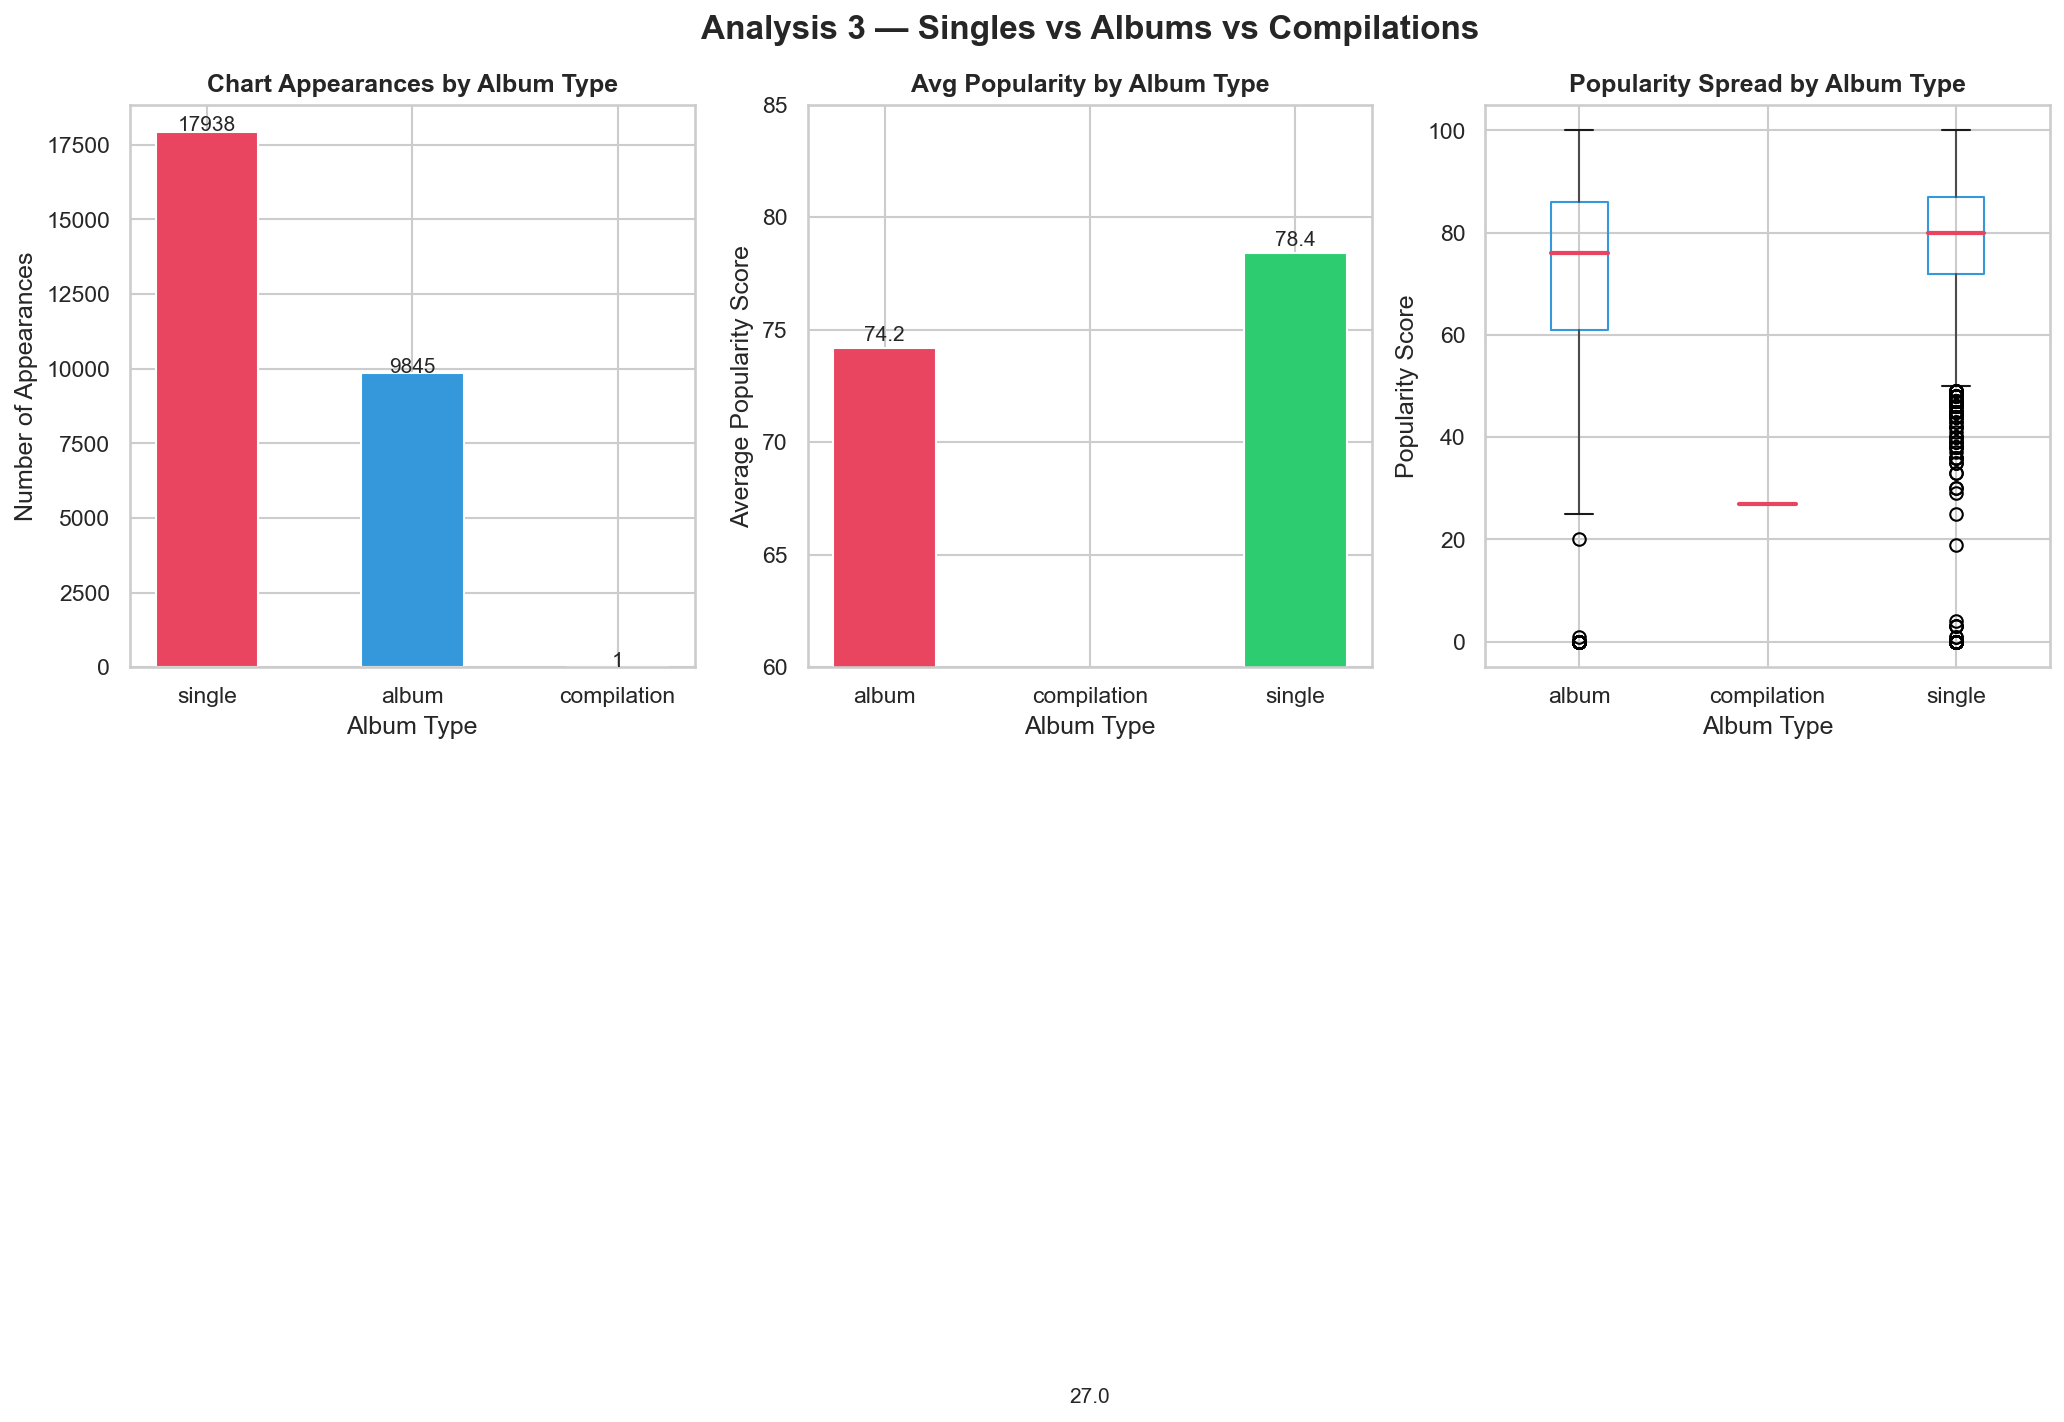

Plot saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

album_counts = df['album_type'].value_counts()
album_avg_pop = df.groupby('album_type')['popularity'].mean().round(2)

# Left — Count of each type
axes[0].bar(album_counts.index, album_counts.values,
            color=['#e94560', '#3498db', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title('Chart Appearances by Album Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Album Type')
axes[0].set_ylabel('Number of Appearances')
for i, v in enumerate(album_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# Middle — Avg popularity by type
axes[1].bar(album_avg_pop.index, album_avg_pop.values,
            color=['#e94560', '#3498db', '#2ecc71'], edgecolor='white', width=0.5)
axes[1].set_title('Avg Popularity by Album Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Album Type')
axes[1].set_ylabel('Average Popularity Score')
axes[1].set_ylim(60, 85)
for i, v in enumerate(album_avg_pop.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha='center', fontsize=10)

# Right — Box plot (shows spread, not just average)
df.boxplot(column='popularity', by='album_type', ax=axes[2],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='#e94560', linewidth=2))
axes[2].set_title('Popularity Spread by Album Type', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Album Type')
axes[2].set_ylabel('Popularity Score')
plt.suptitle('')

plt.suptitle('Analysis 3 — Singles vs Albums vs Compilations', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/03_album_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [9]:
df['year_month'] = df['date'].dt.to_period('M')
monthly = df.groupby('year_month')['popularity'].mean().reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

print("Monthly Average Popularity:")
print(monthly.to_string(index=False))

Monthly Average Popularity:
year_month  popularity
   2024-05   78.528571
   2024-06   79.459333
   2024-07   80.380000
   2024-08   80.543871
   2024-09   78.466667
   2024-10   77.432258
   2024-11   75.362667
   2024-12   76.733548
   2025-01   78.047742
   2025-02   78.549286
   2025-03   77.659704
   2025-04   76.858000
   2025-05   76.935484
   2025-06   74.236000
   2025-07   76.416000
   2025-08   75.815333
   2025-09   74.462000
   2025-10   72.728387
   2025-11   73.442222


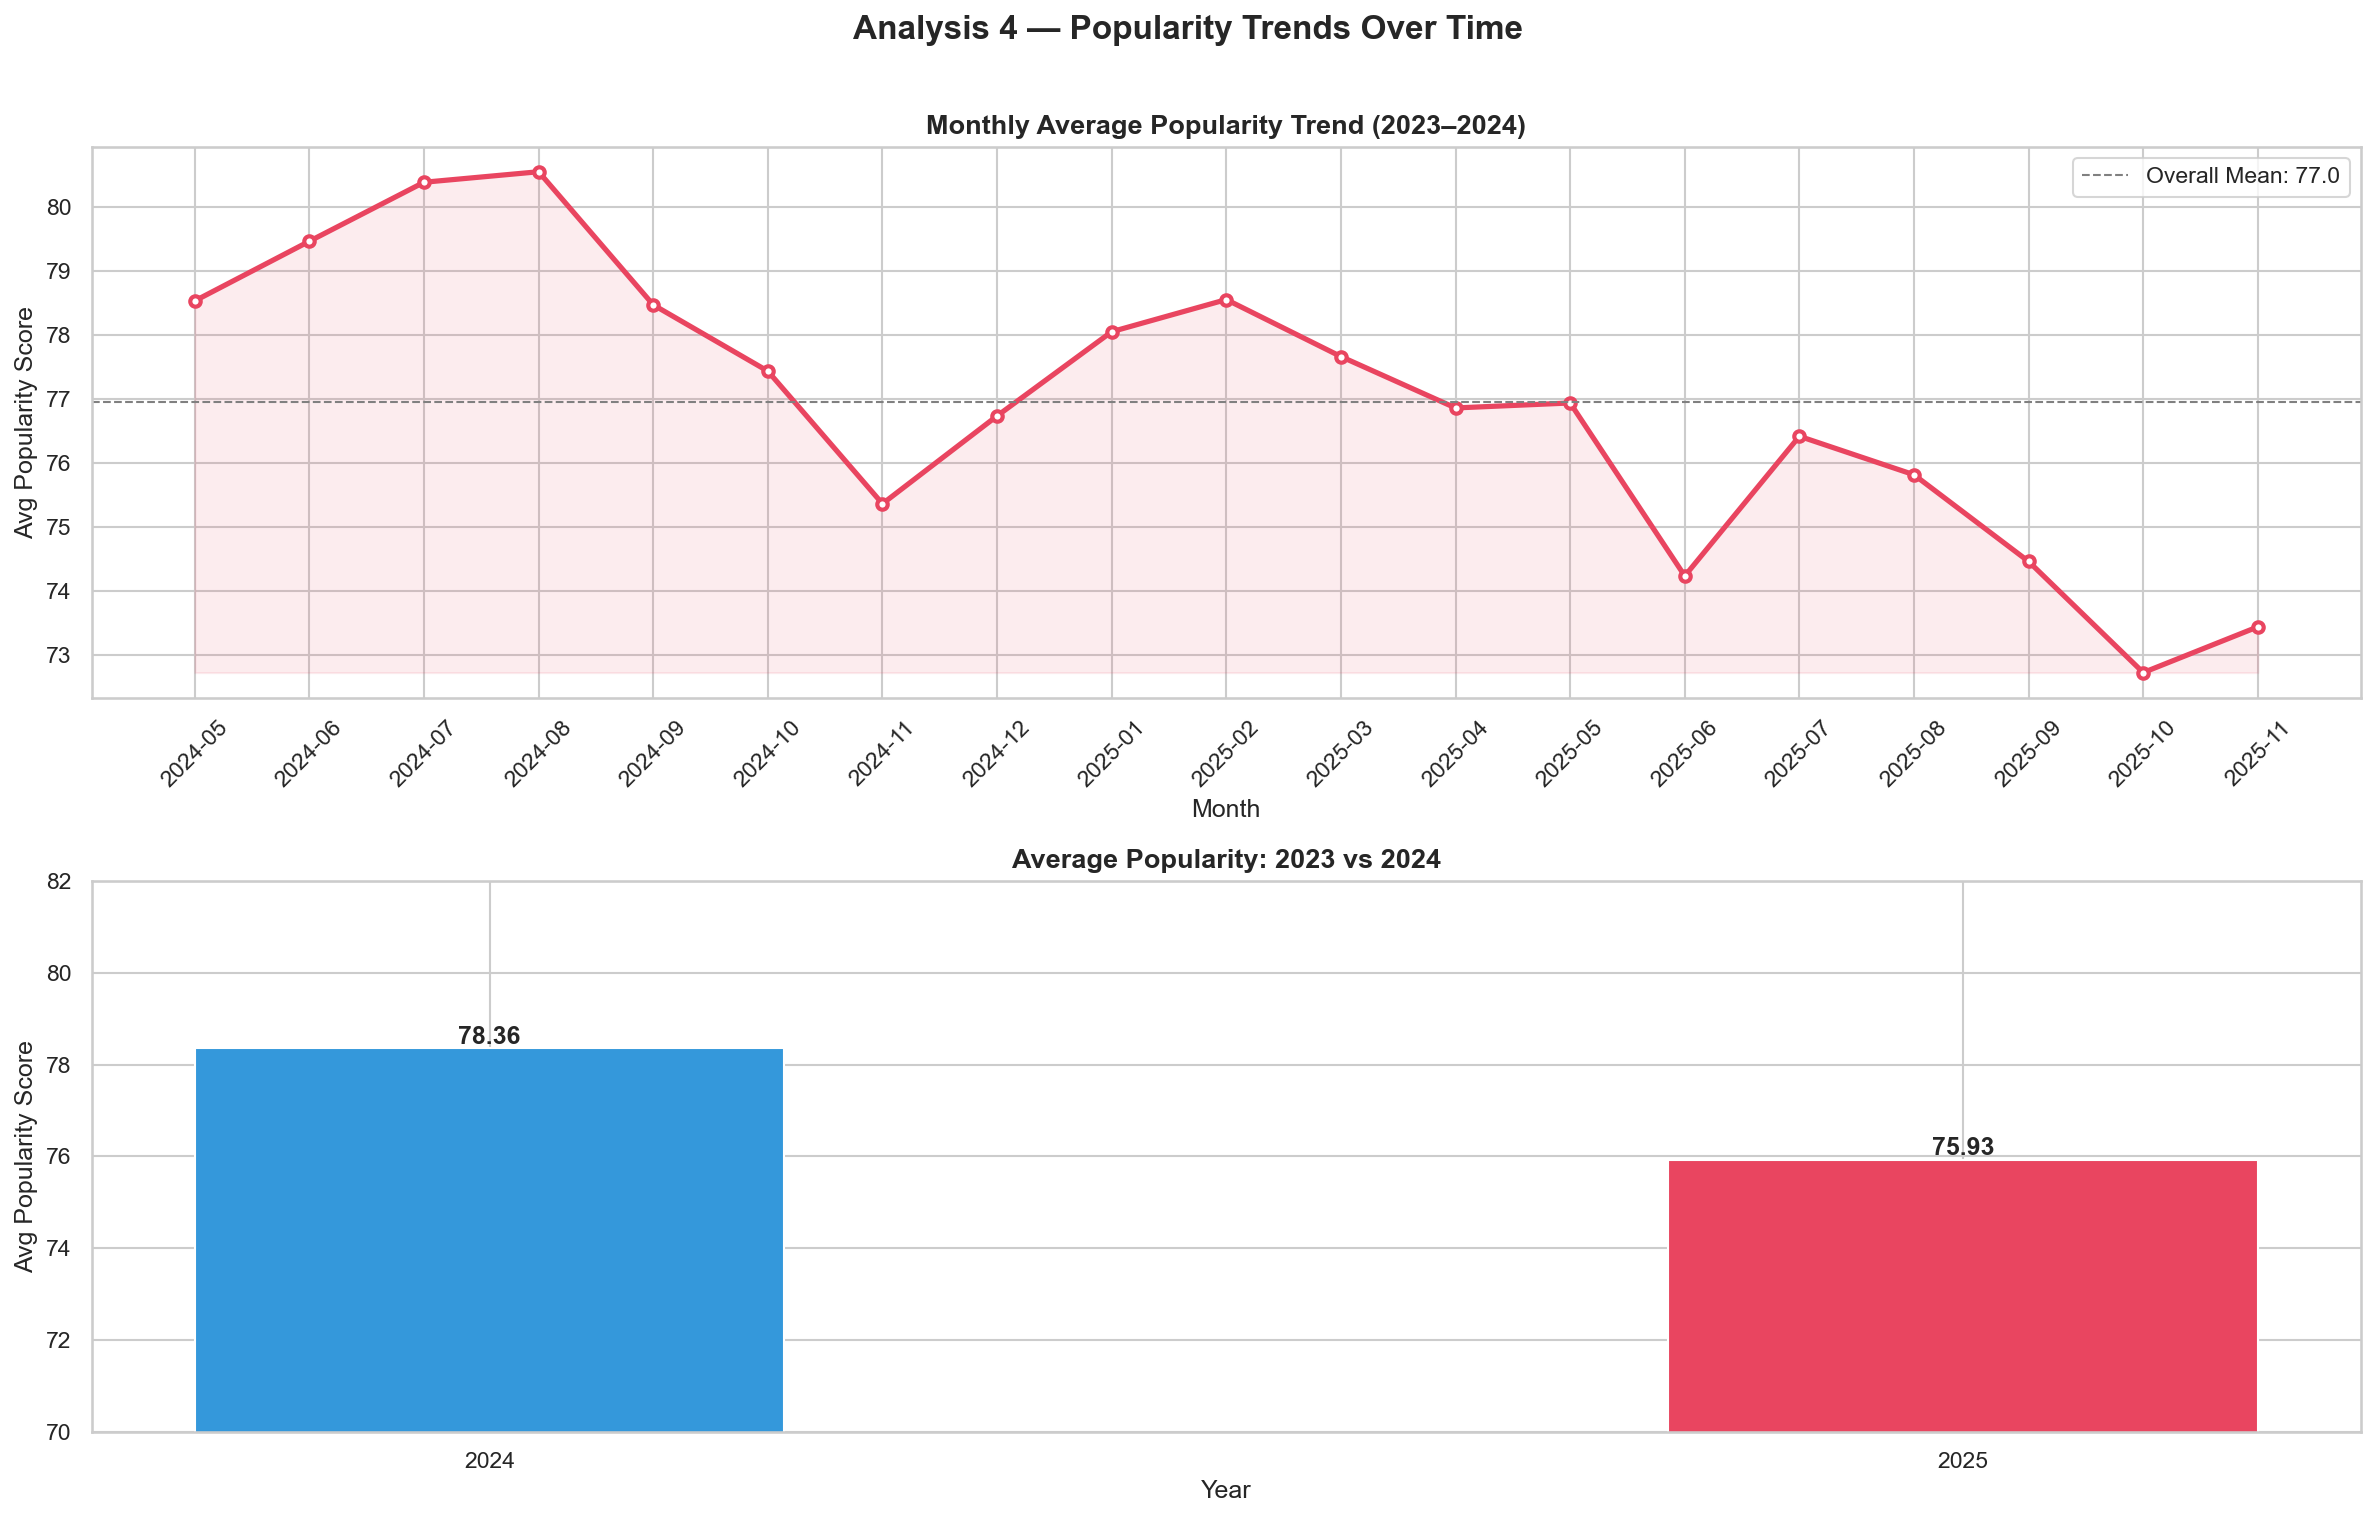

Plot saved!


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top — Monthly trend line
axes[0].plot(monthly['year_month'], monthly['popularity'],
             color='#e94560', linewidth=2.5, marker='o', markersize=5, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(monthly['year_month'], monthly['popularity'],
                     monthly['popularity'].min(), alpha=0.1, color='#e94560')
axes[0].set_title('Monthly Average Popularity Trend (2023–2024)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Popularity Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(monthly['popularity'].mean(), color='gray', linestyle='--',
                linewidth=1, label=f"Overall Mean: {monthly['popularity'].mean():.1f}")
axes[0].legend()

# Bottom — Year comparison (2023 vs 2024)
df['year'] = df['date'].dt.year
yearly = df.groupby('year')['popularity'].mean().reset_index()

bars = axes[1].bar(yearly['year'].astype(str), yearly['popularity'],
                   color=['#3498db', '#e94560'], edgecolor='white', width=0.4)
axes[1].set_title('Average Popularity: 2023 vs 2024', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Popularity Score')
axes[1].set_ylim(70, 82)
for bar, val in zip(bars, yearly['popularity']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val:.2f}", ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Analysis 4 — Popularity Trends Over Time', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/04_popularity_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [12]:
print("Explicit vs Non-Explicit Count:")
print(df['is_explicit'].value_counts())
print(f"\nPercentage Explicit: {df['is_explicit'].mean()*100:.1f}%")
print("\nAvg Popularity by Explicit:")
print(df.groupby('is_explicit')['popularity'].mean().round(2))

Explicit vs Non-Explicit Count:
False    25132
True      2652
Name: is_explicit, dtype: int64

Percentage Explicit: 9.5%

Avg Popularity by Explicit:
is_explicit
False    76.27
True     83.14
Name: popularity, dtype: float64


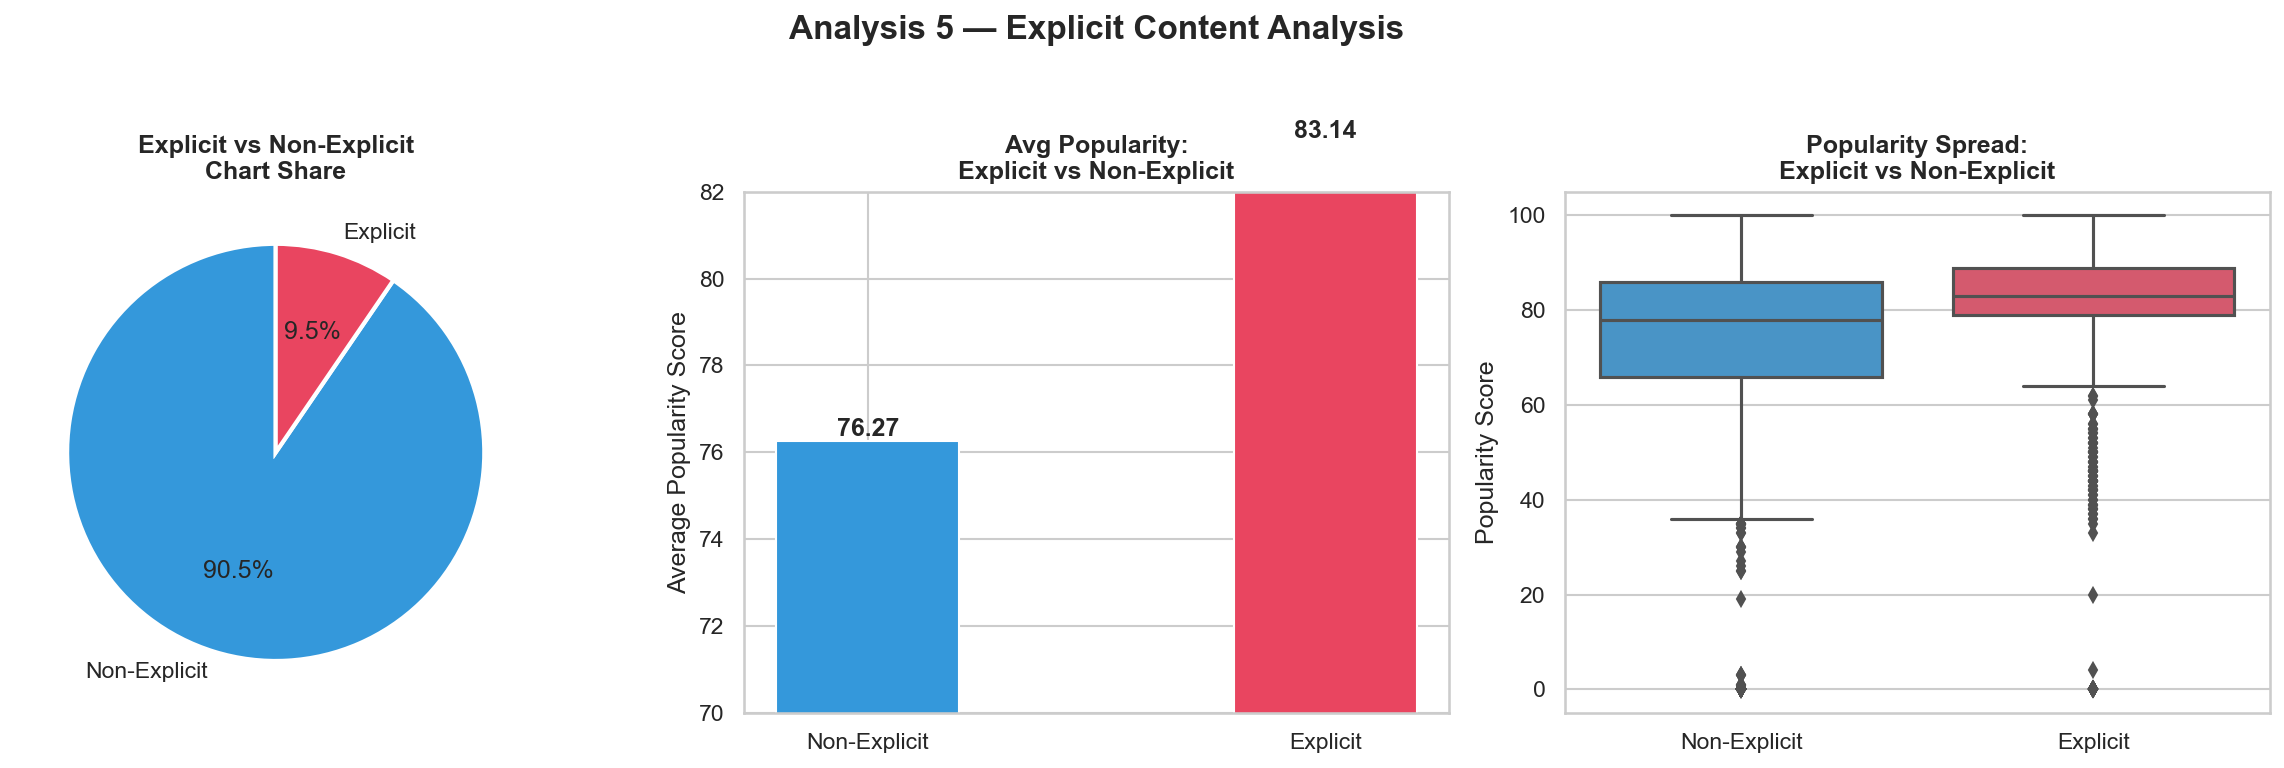

Plot saved!


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

explicit_counts = df['is_explicit'].value_counts()
labels = ['Non-Explicit', 'Explicit']
colors = ['#3498db', '#e94560']

# Left — Pie chart
axes[0].pie(explicit_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Explicit vs Non-Explicit\nChart Share', fontsize=12, fontweight='bold')

# Middle — Avg popularity comparison
exp_pop = df.groupby('is_explicit')['popularity'].mean()
bars = axes[1].bar(['Non-Explicit', 'Explicit'], exp_pop.values,
                   color=colors, edgecolor='white', width=0.4)
axes[1].set_title('Avg Popularity:\nExplicit vs Non-Explicit', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Popularity Score')
axes[1].set_ylim(70, 82)
for bar, val in zip(bars, exp_pop.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val:.2f}", ha='center', fontsize=12, fontweight='bold')

# Right — Box plot
df['explicit_label'] = df['is_explicit'].map({True: 'Explicit', False: 'Non-Explicit'})
sns.boxplot(data=df, x='explicit_label', y='popularity',
            palette={'Explicit': '#e94560', 'Non-Explicit': '#3498db'}, ax=axes[2])
axes[2].set_title('Popularity Spread:\nExplicit vs Non-Explicit', fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Popularity Score')

plt.suptitle('Analysis 5 — Explicit Content Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/05_explicit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [15]:
numeric_cols = ['position', 'popularity', 'duration_min', 'total_tracks']
print("Correlation with Popularity:")
print(df[numeric_cols].corr()['popularity'].sort_values(ascending=False).round(3))

Correlation with Popularity:
popularity      1.000
total_tracks   -0.117
duration_min   -0.255
position       -0.262
Name: popularity, dtype: float64


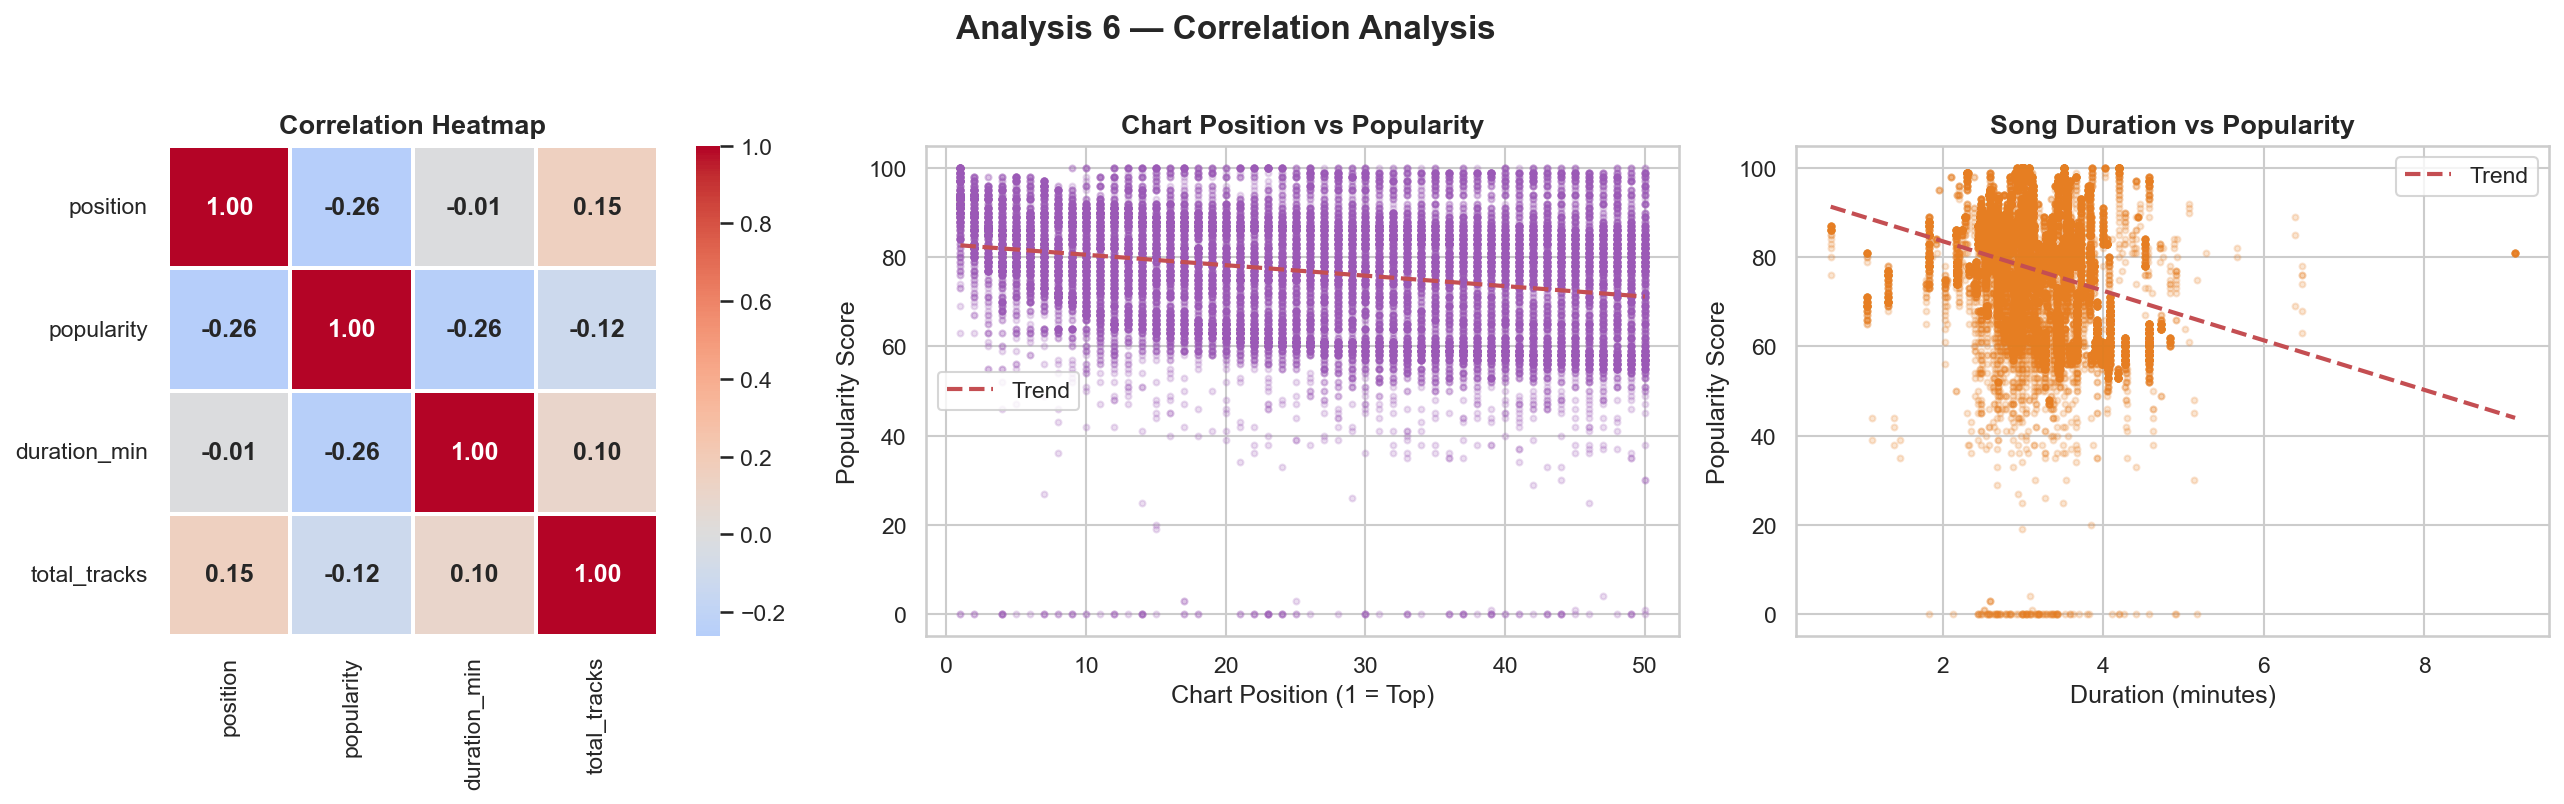

Plot saved!


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left — Correlation Heatmap
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1,
            annot_kws={'size': 12, 'weight': 'bold'}, ax=axes[0])
axes[0].set_title('Correlation Heatmap', fontsize=13, fontweight='bold')

# Middle — Position vs Popularity scatter
axes[1].scatter(df['position'], df['popularity'],
                alpha=0.2, color='#9b59b6', s=8)
z = np.polyfit(df['position'], df['popularity'], 1)
p = np.poly1d(z)
axes[1].plot(sorted(df['position'].unique()),
             p(sorted(df['position'].unique())),
             'r--', linewidth=2, label='Trend')
axes[1].set_title('Chart Position vs Popularity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Chart Position (1 = Top)')
axes[1].set_ylabel('Popularity Score')
axes[1].legend()

# Right — Duration vs Popularity scatter
axes[2].scatter(df['duration_min'], df['popularity'],
                alpha=0.2, color='#e67e22', s=8)
z2 = np.polyfit(df['duration_min'], df['popularity'], 1)
p2 = np.poly1d(z2)
axes[2].plot(sorted(df['duration_min'].unique()),
             p2(sorted(df['duration_min'].unique())),
             'r--', linewidth=2, label='Trend')
axes[2].set_title('Song Duration vs Popularity', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Duration (minutes)')
axes[2].set_ylabel('Popularity Score')
axes[2].legend()

plt.suptitle('Analysis 6 — Correlation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/06_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [18]:
print("=" * 55)
print("        EDA KEY FINDINGS SUMMARY")
print("=" * 55)
print("""
DATASET
  - 27,784 records | Top 40 Daily Chart | 2023–2024
  - 194 unique artists | 527 unique songs

FINDING 1 — Popularity Distribution
  - Mean popularity: 76.9/100
  - Two listener segments: moderate (60s) & high (85+)
  - Small group of songs with near-zero popularity
    (local Korean songs with low global reach)

FINDING 2 — Artist Dominance
  - Korean artists dominate chart frequency
    (Lim Young Woong: 4801 appearances, Jimin: 4359)
  - Western artists lead popularity scores
    (Mariah Carey: 99.8, Jack Harlow: 99.0)

FINDING 3 — Singles vs Albums
  - Singles dominate both chart appearances & popularity
  - Compilations are nearly absent (only 1 record)

FINDING 4 — Popularity Trends Over Time
  - 2024 slightly outperforms 2023 (76.93 vs 76.39)
  - Seasonal fluctuations visible in monthly trend

FINDING 5 — Explicit Content
  - Only 9.5% of chart songs are explicit
  - Explicit songs score 7 points higher (83.14 vs 76.27)

FINDING 6 — Correlation Analysis
  - Position vs Popularity: weak (-0.26)
  - Duration vs Popularity: negligible (-0.01)
  - Popularity driven by artist fame, not audio features
""")
print("=" * 55)

        EDA KEY FINDINGS SUMMARY

DATASET
  - 27,784 records | Top 40 Daily Chart | 2023–2024
  - 194 unique artists | 527 unique songs

FINDING 1 — Popularity Distribution
  - Mean popularity: 76.9/100
  - Two listener segments: moderate (60s) & high (85+)
  - Small group of songs with near-zero popularity
    (local Korean songs with low global reach)

FINDING 2 — Artist Dominance
  - Korean artists dominate chart frequency
    (Lim Young Woong: 4801 appearances, Jimin: 4359)
  - Western artists lead popularity scores
    (Mariah Carey: 99.8, Jack Harlow: 99.0)

FINDING 3 — Singles vs Albums
  - Singles dominate both chart appearances & popularity
  - Compilations are nearly absent (only 1 record)

FINDING 4 — Popularity Trends Over Time
  - 2024 slightly outperforms 2023 (76.93 vs 76.39)
  - Seasonal fluctuations visible in monthly trend

FINDING 5 — Explicit Content
  - Only 9.5% of chart songs are explicit
  - Explicit songs score 7 points higher (83.14 vs 76.27)

FINDING 6 — Corr